In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# LOADING THE LABELED DATA
try:
    df = pd.read_excel('labeled_final_dataset.xlsx')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'labeled_final_dataset.xlsx' not found.")
    exit()

# SEPARATING FEATURES (X) AND TARGET (y)
y = df['BPL_Target']

# Identifying direct income columns to drop (preventing Target Leakage)
# Wanting the model to learn based on jobs, vehicles, and assets, not direct income counts.
income_cols = [col for col in df.columns if col.startswith('in') and any(char.isdigit() for char in col)]

cols_to_drop = ['hasfamilyid', 'BPL_Target', 'familyRange', 'district', 'RuralUrban', 'isChild', 'isHousewife', 'isSenior Citizen', 'isStudent'] + income_cols 
# Comment '+ income_cols' and the lines of code above the comment in the 100-Families.ipynb to add the Per Member Salary to the training dataset
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print(f"Total features selected for training: {X.shape[1]}")


# STRATIFYING TRAIN-TEST SPLIT
# 'stratify=y' guarantees that the imbalance ratio is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print(f"Training set size: {X_train.shape[0]} families")
print(f"Testing set size: {X_test.shape[0]} families")

# BUILDING THE BALANCED PIPELINE
# class_weight='balanced' automatically adjusts the algorithm's math to handle the imbalance
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# STRATIFIED CROSS-VALIDATION
print("\n--- Running 5-Fold Stratified Cross-Validation ---")
# This tests the model 5 times on different slices of the training data
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Using 'f1_macro' because it evaluates both classes equally despite the imbalance
cv_results = cross_validate(pipeline, X_train, y_train, cv=cv_strategy, scoring=['f1_macro', 'accuracy'])

mean_f1 = np.mean(cv_results['test_f1_macro'])
std_f1 = np.std(cv_results['test_f1_macro'])
print(f"Cross-Validation Macro F1-Score: {mean_f1:.4f} (± {std_f1:.4f})")
if std_f1 > 0.1:
    print("Note: High standard deviation indicates the model's performance fluctuates depending on the data slice.")

# FINAL TRAINING & EVALUATION ON UNSEEN TEST DATA
print("\n--- Final Model Evaluation on Unseen Test Data ---")
# Training the model on the full training set
pipeline.fit(X_train, y_train)

# Predicting on the unseen 20% testing set
y_pred = pipeline.predict(X_test)

# Displaying the classification report and confusion matrix
print("\nClassification Report:")
# Target names mapped to our labels
print(classification_report(y_test, y_pred, target_names=['Non-BPL (0)', 'BPL (1)']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"True Negatives (Correct Non-BPL): {cm[0][0]}")
print(f"False Positives (Fraudulent BPL Guesses): {cm[0][1]}")
print(f"False Negatives (Missed BPL Families): {cm[1][0]}")
print(f"True Positives (Correct BPL): {cm[1][1]}")

Dataset loaded successfully.
Total features selected for training: 12
Training set size: 80 families
Testing set size: 20 families

--- Running 5-Fold Stratified Cross-Validation ---
Cross-Validation Macro F1-Score: 0.6861 (± 0.1050)
Note: High standard deviation indicates the model's performance fluctuates depending on the data slice.

--- Final Model Evaluation on Unseen Test Data ---

Classification Report:
              precision    recall  f1-score   support

 Non-BPL (0)       0.88      0.88      0.88         8
     BPL (1)       0.92      0.92      0.92        12

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20

Confusion Matrix:
True Negatives (Correct Non-BPL): 7
False Positives (Fraudulent BPL Guesses): 1
False Negatives (Missed BPL Families): 1
True Positives (Correct BPL): 11


C:\Users\Harsh Datt\AppData\Local\Temp\ipykernel_24052\2156841752.py:30: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


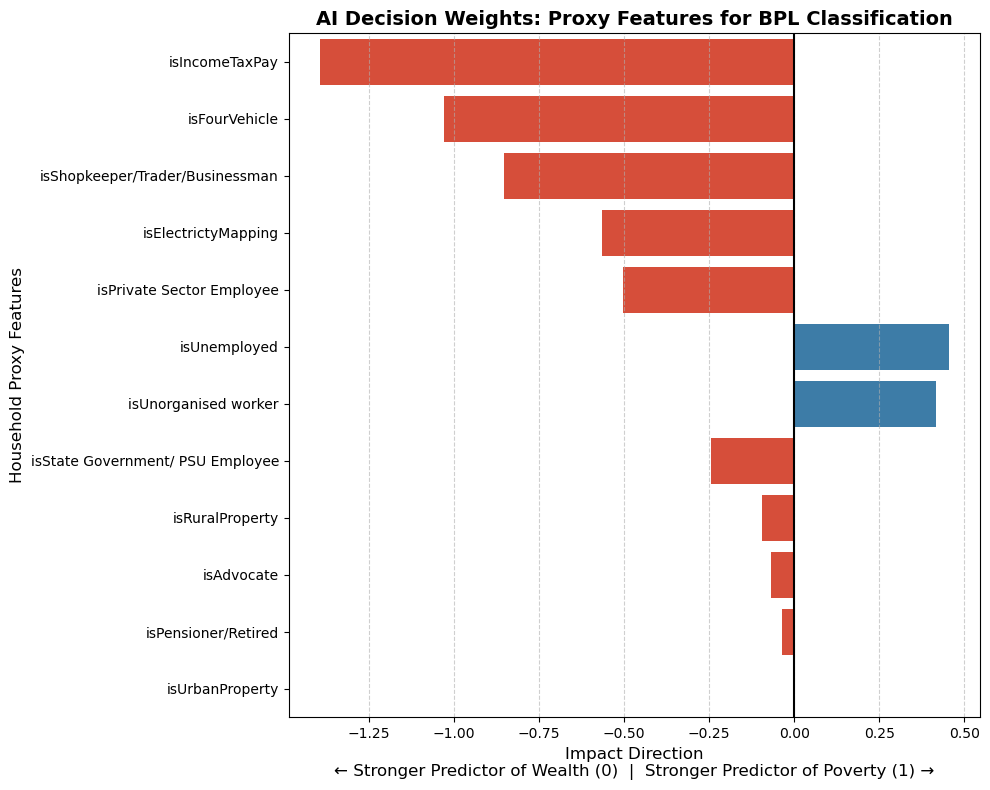


--- Top 5 Most Impactful Features ---
                        Feature  Importance
                 isIncomeTaxPay   -1.393691
                  isFourVehicle   -1.029644
isShopkeeper/Trader/Businessman   -0.852166
            isElectrictyMapping   -0.565415
      isPrivate Sector Employee   -0.502017


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# EXTRACTING WEIGHTS FROM THE PIPELINE
# Digging into the pipeline to get the trained Logistic Regression algorithm
classifier = pipeline.named_steps['classifier']

# Getting the coefficients (the mathematical weights it assigned to each column)
coefficients = classifier.coef_[0]
feature_names = X_train.columns

# BUILDING A SORTED DATAFRAME
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

# Creating an absolute value column so we can sort by the strongest impact (regardless of direction)
feature_importance_df['Absolute_Importance'] = feature_importance_df['Importance'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Absolute_Importance', ascending=False)

# PLOTING THE VISUALIZATION
plt.figure(figsize=(10, 8))

# Color code: Blue = pushes toward BPL (1), Red = pushes toward Non-BPL (0)
colors = np.where(feature_importance_df['Importance'] > 0, '#2c7fb8', '#f03b20')

sns.barplot(
    data=feature_importance_df, 
    x='Importance', 
    y='Feature', 
    palette=colors,
    hue='Feature',
    legend=False
)

plt.title('AI Decision Weights: Proxy Features for BPL Classification', fontsize=14, fontweight='bold')
plt.xlabel('Impact Direction\n← Stronger Predictor of Wealth (0)  |  Stronger Predictor of Poverty (1) →', fontsize=12)
plt.ylabel('Household Proxy Features', fontsize=12)

# Drawing a black line at zero for clarity
plt.axvline(0, color='black', linewidth=1.5)  
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Saving the chart so it can be inserted directly into our project report!
plt.savefig('Feature_Importances_Chart.png', dpi=300)
plt.show()


# PRINTING SUMMARY FOR TERMINAL
print("\n--- Top 5 Most Impactful Features ---")
print(feature_importance_df[['Feature', 'Importance']].head(5).to_string(index=False))

In [3]:
!pip install shap


--- Starting SHAP Error Analysis ---
Total mistakes isolated: 2
  -> False Positives (Guessed BPL, Actually Non-BPL): 1
  -> False Negatives (Guessed Non-BPL, Actually BPL): 1

Calculating SHAP values for the mistakes...


PermutationExplainer explainer: 3it [00:10,  5.40s/it]                                                                 



Visualizing 1 FALSE POSITIVE(S)...


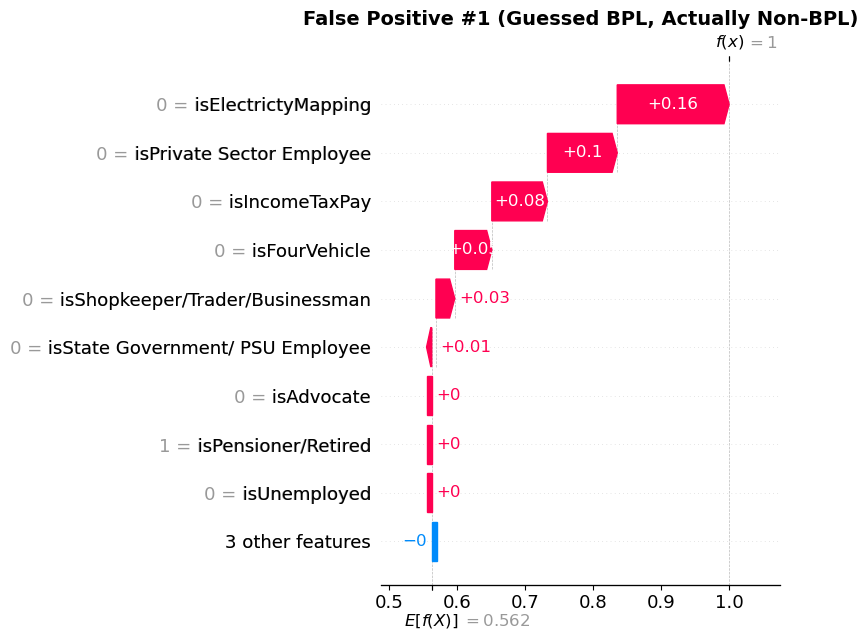


Visualizing 1 FALSE NEGATIVE(S)...


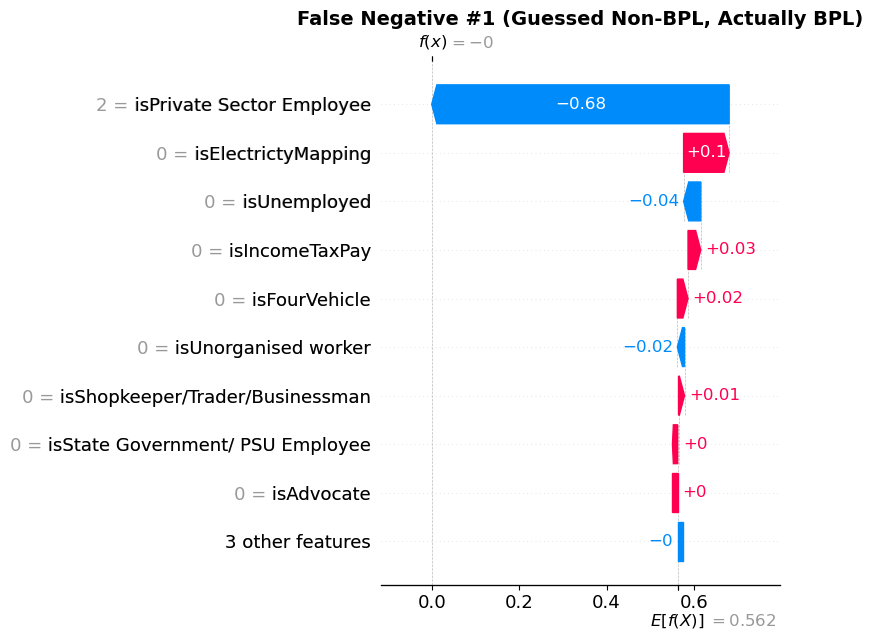

In [4]:
import shap
import matplotlib.pyplot as plt

# SHAP ERROR ANALYSIS PIPELINE
print("\n--- Starting SHAP Error Analysis ---")

# ISOLATING THE MISTAKES
# Creating a copy of the test set and adding the actual and predicted answers
results_df = X_test.copy()
results_df['Actual_BPL'] = y_test
results_df['Predicted_BPL'] = y_pred

# Filtering the dataframe to only keep the rows where the model was wrong
mistakes = results_df[results_df['Actual_BPL'] != results_df['Predicted_BPL']]

# Separating them into False Positives and False Negatives
false_positives = mistakes[mistakes['Predicted_BPL'] == 1]
false_negatives = mistakes[mistakes['Predicted_BPL'] == 0]

print(f"Total mistakes isolated: {len(mistakes)}")
print(f"  -> False Positives (Guessed BPL, Actually Non-BPL): {len(false_positives)}")
print(f"  -> False Negatives (Guessed Non-BPL, Actually BPL): {len(false_negatives)}\n")

# DYNAMIC SHAP CALCULATION
if len(mistakes) == 0:
    # If the model is 100% accurate, skip SHAP entirely!
    print("🎉 Incredible! The model made ZERO mistakes on the test set. No SHAP analysis needed.")

else:
    # Initializing SHAP only if there are mistakes to explain
    print("Calculating SHAP values for the mistakes...")
    mistakes_features = mistakes.drop(columns=['Actual_BPL', 'Predicted_BPL'])
    explainer = shap.Explainer(pipeline.predict, X_train)
    
    # Calculating the SHAP values for all mistakes at once
    shap_values = explainer(mistakes_features)

    # VISUALIZING ALL FALSE POSITIVES
    if not false_positives.empty:
        print(f"\nVisualizing {len(false_positives)} FALSE POSITIVE(S)...")
        # Looping through every False Positive dynamically
        for i, idx in enumerate(false_positives.index):
            # Getting the relative index inside our mistakes dataframe
            fp_idx = mistakes.index.get_loc(idx)
            
            plt.figure(figsize=(10, 6))
            shap.plots.waterfall(shap_values[fp_idx], show=False)
            plt.title(f"False Positive #{i+1} (Guessed BPL, Actually Non-BPL)", fontsize=14, fontweight='bold')
            plt.tight_layout()
            
            # Saving each image with a unique number
            plt.savefig(f'SHAP_False_Positive_{i+1}.png', dpi=300)
            plt.show()
            plt.close() # Clears memory so Jupyter doesn't crash on large datasets

    # VISUALIZING ALL FALSE NEGATIVES
    if not false_negatives.empty:
        print(f"\nVisualizing {len(false_negatives)} FALSE NEGATIVE(S)...")
        # Looping through every False Negative dynamically
        for i, idx in enumerate(false_negatives.index):
            # Getting the relative index inside our mistakes dataframe
            fn_idx = mistakes.index.get_loc(idx)
            
            plt.figure(figsize=(10, 6))
            shap.plots.waterfall(shap_values[fn_idx], show=False)
            plt.title(f"False Negative #{i+1} (Guessed Non-BPL, Actually BPL)", fontsize=14, fontweight='bold')
            plt.tight_layout()
            
            # Saving each image with a unique number
            plt.savefig(f'SHAP_False_Negative_{i+1}.png', dpi=300)
            plt.show()
            plt.close() # Clears memory

In [5]:
mistakes

,isAdvocate,isPensioner/Retired,isPrivate Sector Employee,isShopkeeper/Trader/Businessman,isState Government/ PSU Employee,isUnemployed,isUnorganised worker,isIncomeTaxPay,isRuralProperty,isUrbanProperty,isElectrictyMapping,isFourVehicle,Actual_BPL,Predicted_BPL
69,0,1,0,0,0,0,0,0,2,0,0,0,0,1
34,0,0,2,0,0,0,0,0,0,0,0,0,1,0


In [6]:
# The changes only apply within this 'with' block
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df)

,hasfamilyid,isAdvocate,isChild,isHousewife,isPensioner/Retired,isPrivate Sector Employee,isSenior Citizen,isShopkeeper/Trader/Businessman,isState Government/ PSU Employee,isStudent,isUnemployed,isUnorganised worker,isIncomeTaxPay,isRuralProperty,isUrbanProperty,isElectrictyMapping,isFourVehicle,district,RuralUrban,familyRange,BPL_Target
0,02B7D6E10864ADC76F128FAA63463F664AFA434427C309...,0,0,1,0,1,0,0,0,2,0,0,0,0,0,0,0,FARIDABAD,U,100001-140000,1
1,07516016FBDC9EC937110105951430287DCB676941B037...,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,BHIWANI,R,180001-300000,0
2,080427E25CA420D620C940BAC62B5A376812720BFD77A9...,0,0,0,0,1,0,0,0,3,0,1,0,0,0,1,0,FARIDABAD,U,140001-180000,1
3,0B7E546649288A1B8D32C96AF1E2C66E05E5C203CC575A...,0,0,1,0,0,0,0,0,3,0,0,0,0,0,1,0,NUH,R,100001-140000,1
4,0D5F0E7DA8D0F001AFFFAF6D5FBF3BEAB22EB79470726E...,0,1,1,0,3,1,0,0,2,0,0,0,2,0,2,0,GURUGRAM,R,500001-600000,0
5,0FCC96C0227EA367198E71C85D13E62D1B9BEA7951AA07...,0,1,2,0,0,0,0,0,2,0,0,0,0,0,0,0,PANCHKULA,U,140001-180000,1
6,111F272A3F3B5F4106964C80C931D98CA703AC6C8D44E8...,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,HISAR,R,50001-75000,1
7,124158D67826C85056CCAC29CDD0B1A0168A87B4FF79FB...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,MAHENDERGARH,R,100001-140000,1
8,12921666B508B4084B23D71ECDFC7DD96066829446F588...,0,0,2,0,0,1,0,0,2,0,0,2,0,0,2,0,JIND,R,500001-600000,0
9,19E4AB00E4E008D3C43625B374B55F76529E6BE968F0A2...,0,0,0,0,1,0,0,0,3,0,0,0,0,0,0,0,KARNAL,R,75001-100000,1
